In [27]:
from parse import data as parse
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks as fp
import scipy.fft as fft

ch1,ch2,t = parse(open("data/SDS00098.bin","rb"))
ch1 *= 10
ch2 *= 10

max at SDS00487

In [28]:
FFT = np.abs(fft.rfft(ch1))
freqs = fft.rfftfreq(ch1.size,t[1])
temp = np.argwhere(freqs>0)
freqs = np.log10(freqs[temp]).ravel()
temp = np.argwhere((freqs<3.7) & (freqs > 1.5))
freqs = freqs[temp].ravel()
FFT = np.log10(FFT[temp]).ravel()

In [29]:
print(FFT.ravel().shape)
print(freqs.ravel().shape)
temp = fp(FFT,prominence=1)[0]

(348,)
(348,)


In [30]:
N = len(ch1)//8
tempf = np.average(10**(freqs[temp]))
print(tempf)

3128.5712044464053


In [31]:
tempt = t[:N]
temp1 = ch1[:N]
tempN = N/(tempf*tempt[-1])
Ntemp1 = -temp1
Ntemp1 -= np.min(Ntemp1)
print(tempN)

63926.97718236743


28
28


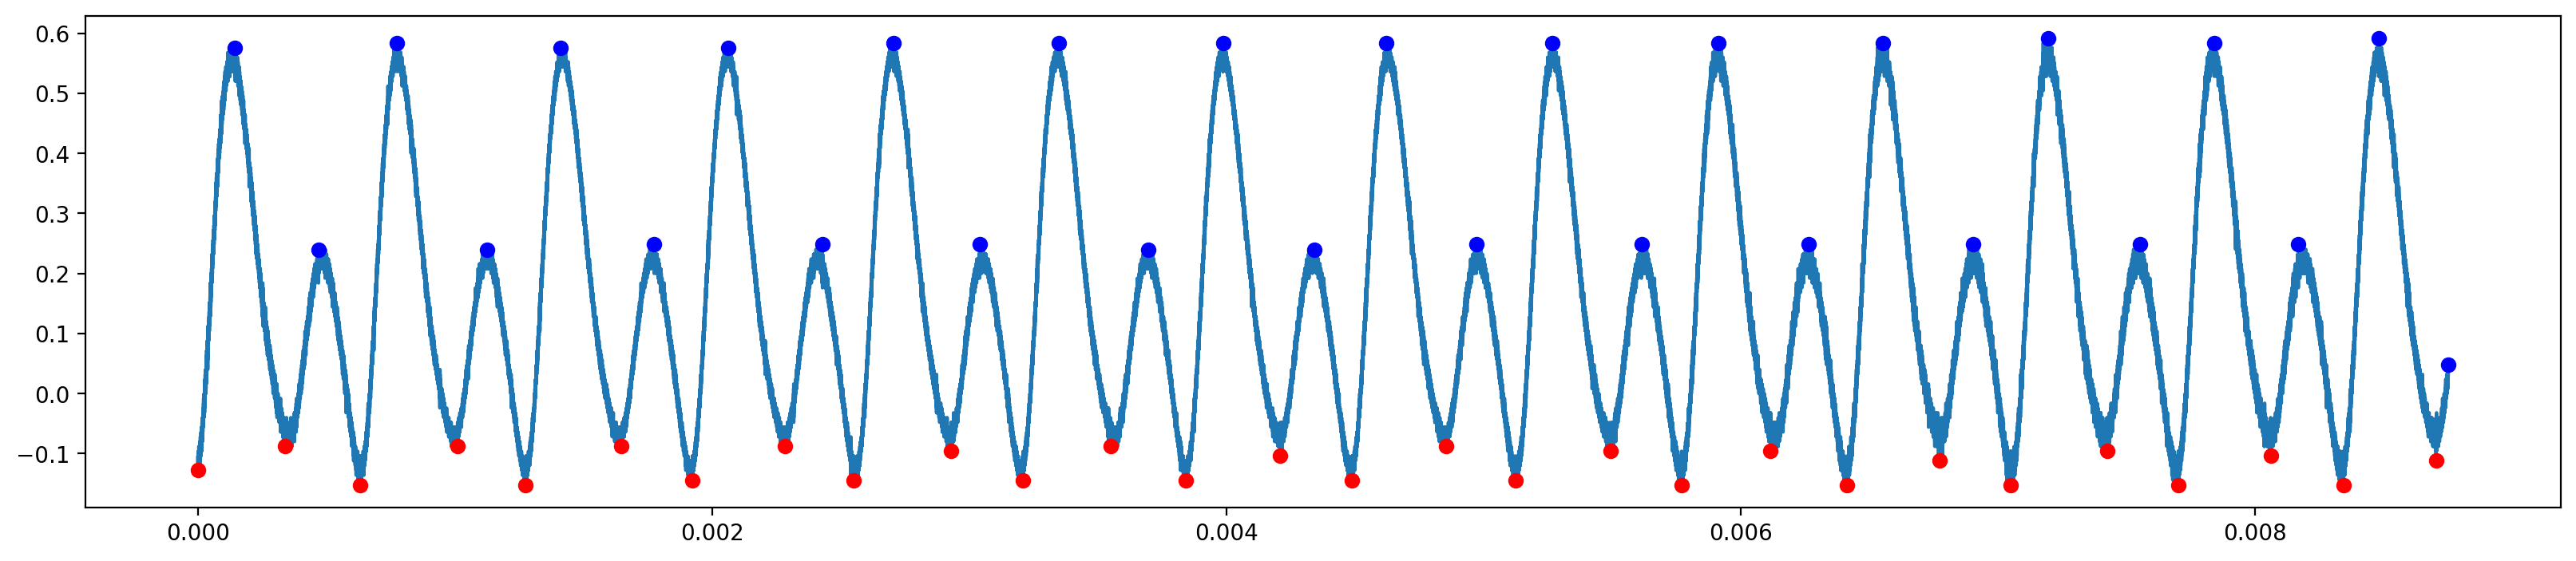

In [32]:
#31
R = 0.0
n = fp(temp1,distance=tempN/(1.5))[0]
m = fp(Ntemp1,distance=tempN/(1.5))[0]
print(len(n))
print(len(m))
ntempt = tempt[n]
ntemp1 = temp1[n]
mtempt = tempt[m]
mtemp1 = temp1[m]
plt.figure(figsize=(20,4),dpi=200)
plt.plot(tempt,temp1)
plt.plot(ntempt,ntemp1,'bo')
plt.plot(mtempt,mtemp1,'ro')
plt.show()

In [33]:
print(tempN)
print(n)
print(m)
print(type(n))

63926.97718236743
[  28890   93792  154592  224684  282057  354572  412363  485482  541065
  608078  669535  738854  797266  868232  924354  994220 1053540 1122522
 1182215 1252337 1310602 1380407 1439167 1510161 1567901 1633408 1695933
 1749842]
[     49   67967  126233  201926  254984  329415  384640  456279  509722
  585731  641410  709675  768501  841675  897150  970887 1024707 1098375
 1153806 1223079 1282432 1354353 1409379 1485121 1540194 1611843 1668616
 1740611]
<class 'numpy.ndarray'>


In [34]:
from peak import FIX

In [35]:

def fix(MAXES,MINS):
    ALL = (np.sort(np.append(MAXES,MINS)))
    INDICES = np.array([])
    REMOVED = 0
    for i in range(len(ALL)):
        temp = np.argwhere(MAXES == ALL[i])
        if (temp.size != 0):
            INDICES = np.append(INDICES,1)
        temp = np.argwhere(MINS == ALL[i])
        if (temp.size != 0):
            INDICES = np.append(INDICES,0)
    for i in range(len(INDICES)-1):
        if (INDICES[i] == INDICES[i+1]):
            ALL = np.delete(ALL, i)
    # print(REMOVE)
    # ALL = np.delete(ALL,REMOVE)
    
    print(INDICES)
    return ALL

In [36]:
temp = fix(n,m)[1:-1]
# print(np.argwhere(n == 0).size)

[0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1.
 0. 1. 0. 1. 0. 1. 0. 1.]


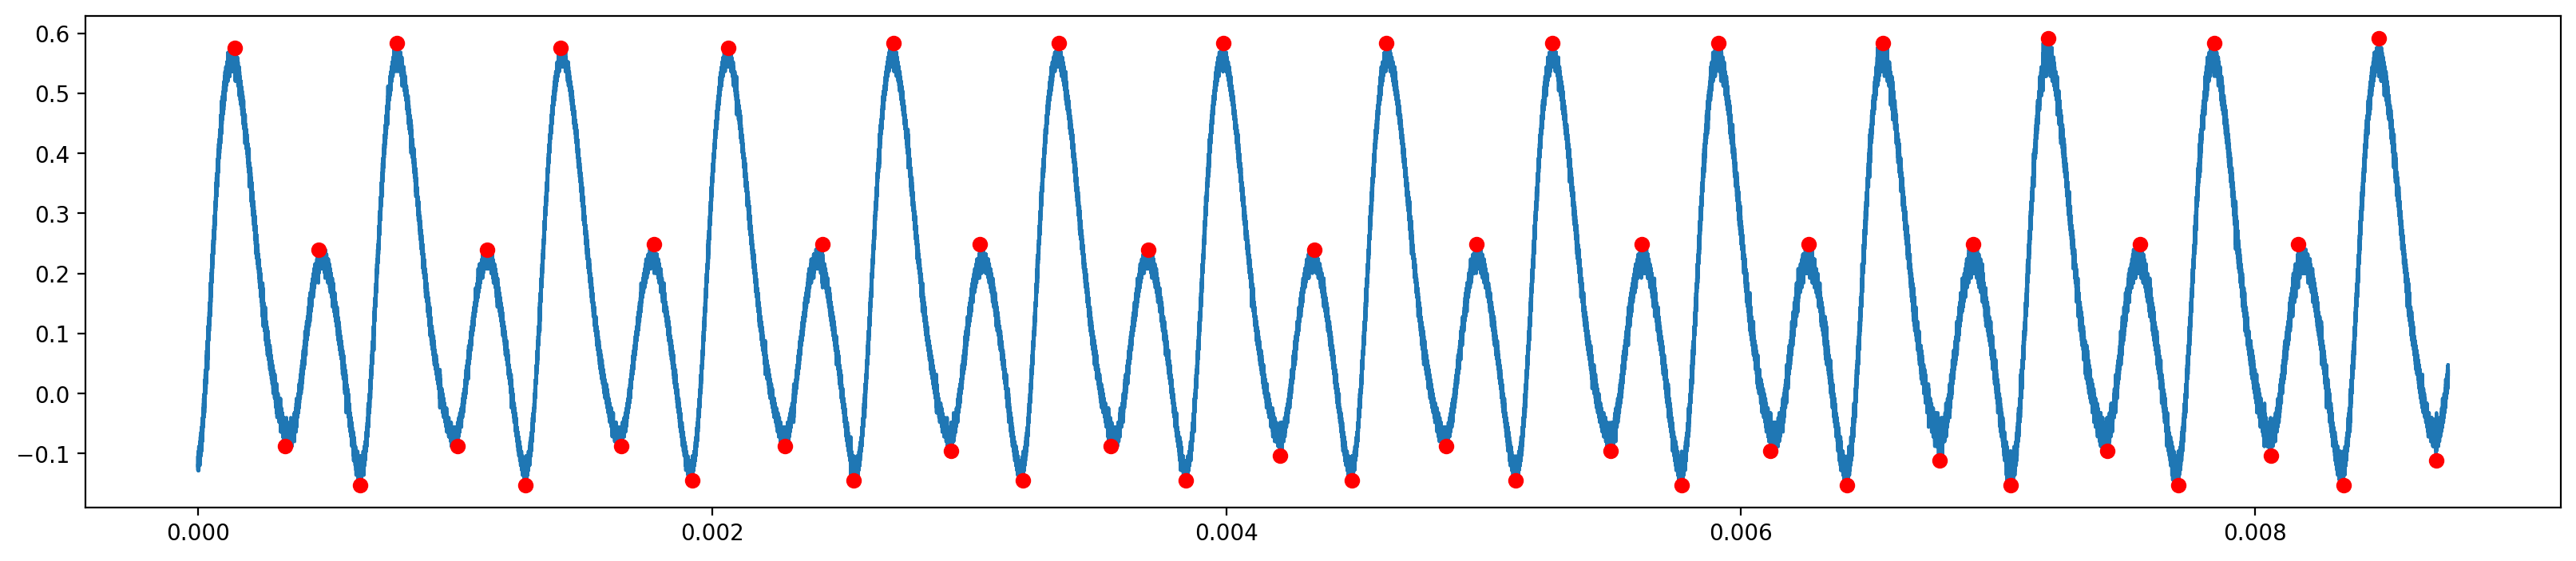

In [37]:

plt.figure(figsize=(20,4),dpi=200)
plt.plot(tempt,temp1)
plt.plot(tempt[temp],temp1[temp],'ro')
# plt.plot(tempt[n],temp1[n],'ro')
# plt.plot(tempt[m],temp1[m],'ro')
plt.show()

In [38]:
def AMPLITUDES(DATA,INDICES):
    AMPS = np.array([])
    for i in range(INDICES.size-1):
        AMPS = np.append(AMPS, np.abs(DATA[INDICES[i]] - DATA[INDICES[i+1]]))
    return AMPS
    

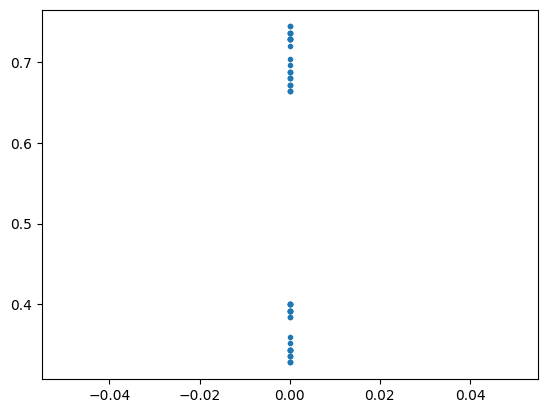

In [39]:
data = AMPLITUDES(temp1, temp)
plt.plot(np.zeros(data.size),data,'.')
plt.show()